# 🚆 Analyse Exploratoire des Données de Transport Public Normands

## 📋 Table des Matières
1. [Introduction](#1-introduction)
2. [Chargement des Données](#2-chargement-des-données)
3. [Extraction et Nettoyage](#3-extraction-et-nettoyage)
4. [Analyse Descriptive](#4-analyse-descriptive)
5. [Cartographie Interactive](#5-cartographie-interactive)
6. [Analyse Avancée](#6-analyse-avancée)
7. [Conclusion et Perspectives](#7-conclusion-et-perspectives)

---

## 1. Introduction

### 🎯 Objectifs du Projet
- Comprendre la distribution des arrêts de transport en Normandie
- Explorer la densité des réseaux et l'accessibilité
- Identifier des zones sous-desservies
- Proposer des pistes d'optimisation

### 📊 Jeu de Données
- **Source** : Données NeTEx Open Data Normandie
- **Format** : XML
- **Période** : 2024
- **Étendue** : Réseau Astrobus

---

## 2. Chargement des Données

```python
import xml.etree.ElementTree as ET
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliothèques importées avec succès")

In [82]:
# Cell 2: Chargement du fichier XML (VOTRE CODE AMÉLIORÉ)
file_path = r"C:\Users\loegn\Downloads\download-offre-tc-noprovider-netex-opendata-27-\PT_TH_OFFER_ASTROBUS_netex_20250909_1088_OPENDATA\Arrets.xml"

try:
    tree = ET.parse(file_path)
    root = tree.getroot()
    print("✅ Fichier XML chargé avec succès")
    print(f"📁 Élément racine : {root.tag}")
    print(f"🔍 Namespace détecté")
except Exception as e:
    print(f"❌ Erreur lors du chargement : {e}")

✅ Fichier XML chargé avec succès
📁 Élément racine : {http://www.netex.org.uk/netex}PublicationDelivery
🔍 Namespace détecté


 ## 3. Extraction et Nettoyage des Données

In [83]:
# Cell 3: Extraction des arrêts (VERSION CORRIGÉE ET AMÉLIORÉE)
ns = {'netex': 'http://www.netex.org.uk/netex'}

# Extraction de tous les StopPlace
stop_places = root.findall('.//netex:StopPlace', namespaces=ns)
liste_arrets = []

print(f"🔍 {len(stop_places)} arrêts détectés dans le fichier XML")

for i, sp in enumerate(stop_places):
    arrest_id = sp.attrib.get('id', 'N/A')
    
    # Extraction du nom
    name_elem = sp.find('netex:Name', namespaces=ns)
    name = name_elem.text if name_elem is not None else 'Nom non disponible'
    
    # Extraction des coordonnées
    centroid = sp.find('netex:Centroid/netex:Location', namespaces=ns)
    longitude, latitude = None, None
    
    if centroid is not None:
        lon_elem = centroid.find('netex:Longitude', namespaces=ns)
        lat_elem = centroid.find('netex:Latitude', namespaces=ns)
        longitude = lon_elem.text if lon_elem is not None else None
        latitude = lat_elem.text if lat_elem is not None else None
    
    liste_arrets.append({
        'id': arrest_id, 
        'name': name, 
        'longitude': longitude, 
        'latitude': latitude
    })

print(f"📊 Extraction terminée : {len(liste_arrets)} arrêts extraits")

🔍 707 arrêts détectés dans le fichier XML
📊 Extraction terminée : 707 arrêts extraits


In [84]:
# Cell 4: Création du DataFrame et nettoyage
df_arrets = pd.DataFrame(liste_arrets)

# Conversion des coordonnées en numérique
df_arrets['longitude'] = pd.to_numeric(df_arrets['longitude'], errors='coerce')
df_arrets['latitude'] = pd.to_numeric(df_arrets['latitude'], errors='coerce')

# Suppression des valeurs manquantes
df_initial_count = len(df_arrets)
df_arrets = df_arrets.dropna(subset=['longitude', 'latitude'])
df_final_count = len(df_arrets)

print(f"🧹 Nettoyage des données :")
print(f"   • Avant nettoyage : {df_initial_count} arrêts")
print(f"   • Après nettoyage : {df_final_count} arrêts")
print(f"   • Données supprimées : {df_initial_count - df_final_count}")

print("\n📊 Aperçu des données :")
display(df_arrets.head(8))

🧹 Nettoyage des données :
   • Avant nettoyage : 707 arrêts
   • Après nettoyage : 707 arrêts
   • Données supprimées : 0

📊 Aperçu des données :


,id,name,longitude,latitude
0,FR:14366:LMO:AUTOPT202410291012232:ATOUMOD000,LISIEUX: tourville,0.254937,49.146425
1,FR:14366:LMO:AUTOPT202410291012234:ATOUMOD000,LISIEUX: tourville,0.254913,49.146381
2,FR:14366:LMO:AUTOPT202410291012236:ATOUMOD000,LISIEUX: stade bielman,0.222174,49.157840
3,FR:14366:LMO:AUTOPT202410291012238:ATOUMOD000,LISIEUX: stade bielman,0.222318,49.157760
4,FR:14366:LMO:AUTOPT2024102910122310:ATOUMOD000,LISIEUX: gare sncf,0.231104,49.138633
5,FR:14366:LMO:AUTOPT2024102910122312:ATOUMOD000,LISIEUX: gare sncf,0.231104,49.138633
6,FR:14366:LMO:AUTOPT2024102910122316:ATOUMOD000,LISIEUX: grand jardin,0.226778,49.150524
7,FR:14366:LMO:AUTOPT2024102910122314:ATOUMOD000,LISIEUX: grand jardin,0.226714,49.150722


In [85]:
# Cell 5: Informations sur le DataFrame
print("📋 INFORMATIONS SUR LE DATAFRAME")
print("=" * 35)
print(f"• Dimensions : {df_arrets.shape[0]} lignes x {df_arrets.shape[1]} colonnes")
print(f"• Mémoire utilisée : {df_arrets.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n• Types de données :")
print(df_arrets.dtypes)

📋 INFORMATIONS SUR LE DATAFRAME
• Dimensions : 707 lignes x 4 colonnes
• Mémoire utilisée : 0.13 MB

• Types de données :
id            object
name          object
longitude    float64
latitude     float64
dtype: object


## 4. Analyse Descriptive de Base

In [86]:
# Cell 6: Métriques fondamentales
print("📈 MÉTRIQUES FONDAMENTALES DU RÉSEAU")
print("=" * 45)

nombre_total_arrets = len(df_arrets)
noms_uniques = df_arrets['name'].nunique()
taux_unicite = (noms_uniques / nombre_total_arrets) * 100

print(f"• Nombre total d'arrêts : {nombre_total_arrets:,}")
print(f"• Noms uniques : {noms_uniques} ({taux_unicite:.1f}%)")
print(f"• Taux de duplication : {100 - taux_unicite:.1f}%")

# Analyse des IDs
ids_uniques = df_arrets['id'].nunique()
print(f"• IDs uniques : {ids_uniques} ({ids_uniques/nombre_total_arrets*100:.1f}%)")

📈 MÉTRIQUES FONDAMENTALES DU RÉSEAU
• Nombre total d'arrêts : 707
• Noms uniques : 376 (53.2%)
• Taux de duplication : 46.8%
• IDs uniques : 707 (100.0%)


In [87]:
# Cell 7: Top 10 des arrêts les plus fréquents
print("\n🏆 TOP 10 DES NOMS D'ARRÊTS LES PLUS FRÉQUENTS")
print("=" * 50)

top_arrets = df_arrets['name'].value_counts().head(10)

for i, (nom, count) in enumerate(top_arrets.items(), 1):
    pourcentage = (count / nombre_total_arrets) * 100
    print(f"{i:2d}. {nom:<45} : {count:2d} occurrence(s) ({pourcentage:.2f}%)")


🏆 TOP 10 DES NOMS D'ARRÊTS LES PLUS FRÉQUENTS
 1. LISIEUX: tourville                            :  2 occurrence(s) (0.28%)
 2. ST LOUP DE FRIBOIS: la maridelle              :  2 occurrence(s) (0.28%)
 3. ST OUEN LE PIN: carrefour                     :  2 occurrence(s) (0.28%)
 4. LE PRE D'AUGE: le bourg                       :  2 occurrence(s) (0.28%)
 5. LE PRE D'AUGE: la bosquetterie                :  2 occurrence(s) (0.28%)
 6. LE PRE D'AUGE: bercy                          :  2 occurrence(s) (0.28%)
 7. LA BOISSIERE: la thibouterie                  :  2 occurrence(s) (0.28%)
 8. LE PIN: mairie                                :  2 occurrence(s) (0.28%)
 9. LE PIN: carrefour                             :  2 occurrence(s) (0.28%)
10. OUILLY DU HOULEY: le pouplin                  :  2 occurrence(s) (0.28%)


In [88]:
# Cell 8: Statistiques géographiques
print("\n🗺️ STATISTIQUES GÉOGRAPHIQUES")
print("=" * 35)

stats_geo = df_arrets[['latitude', 'longitude']].describe()
display(stats_geo)

# Calculs supplémentaires
etendue_lat = df_arrets['latitude'].max() - df_arrets['latitude'].min()
etendue_lon = df_arrets['longitude'].max() - df_arrets['longitude'].min()

print(f"\n📐 Étendue géographique :")
print(f"   • Latitude : {etendue_lat:.3f}° (~{etendue_lat * 111:.1f} km)")
print(f"   • Longitude : {etendue_lon:.3f}° (~{etendue_lon * 111:.1f} km)")


🗺️ STATISTIQUES GÉOGRAPHIQUES


,latitude,longitude
count,707.000000,707.000000
mean,49.081873,0.162927
std,0.065604,0.148005
min,48.915049,-0.135069
25%,49.027236,0.031399
50%,49.089581,0.214634
75%,49.141317,0.273210
max,49.211093,0.421663



📐 Étendue géographique :
   • Latitude : 0.296° (~32.9 km)
   • Longitude : 0.557° (~61.8 km)


## 5. Cartographie Interactive

In [89]:
# Cell 9: Création de la carte interactive
print("🗺️ CRÉATION DE LA CARTE INTERACTIVE")
print("=" * 40)

center_lat = df_arrets['latitude'].mean()
center_lon = df_arrets['longitude'].mean()

print(f"📍 Centre géographique du réseau :")
print(f"   • Latitude : {center_lat:.4f}°N")
print(f"   • Longitude : {center_lon:.4f}°E")

# Création de la carte
carte = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=11,
    tiles='OpenStreetMap',
    control_scale=True
)

# Ajout des marqueurs
for idx, row in df_arrets.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(f"<b>{row['name']}</b><br>ID: {row['id']}", max_width=300),
        tooltip=row['name'],
        icon=folium.Icon(color='blue', icon='bus', prefix='fa')
    ).add_to(carte)

print("✅ Carte interactive générée avec succès")
carte

🗺️ CRÉATION DE LA CARTE INTERACTIVE
📍 Centre géographique du réseau :
   • Latitude : 49.0819°N
   • Longitude : 0.1629°E
✅ Carte interactive générée avec succès


In [90]:
# Cell 10: Sauvegarde de la carte
carte.save("carte_arrets_astrobus.html")
print("💾 Carte sauvegardée sous 'carte_arrets_astrobus.html'")

💾 Carte sauvegardée sous 'carte_arrets_astrobus.html'


 ## 6. Analyse Avancée

In [91]:
# Cell 11: Analyse des localités
print("🏘️ ANALYSE PAR LOCALITÉ")
print("=" * 30)

# Extraction du nom de localité (partie avant ":")
df_arrets['localite'] = df_arrets['name'].str.split(':').str[0].str.strip()

top_localites = df_arrets['localite'].value_counts().head(10)

print("Top 10 des localités les plus desservies :")
for i, (localite, count) in enumerate(top_localites.items(), 1):
    pourcentage = (count / len(df_arrets)) * 100
    print(f"{i:2d}. {localite:<25} : {count:3d} arrêts ({pourcentage:.1f}%)")

print(f"\n• Total localités uniques : {df_arrets['localite'].nunique()}")

🏘️ ANALYSE PAR LOCALITÉ
Top 10 des localités les plus desservies :
 1. LISIEUX                   : 134 arrêts (19.0%)
 2. HERMIVAL LES VAUX         :  21 arrêts (3.0%)
 3. LE MESNIL MAUGER          :  21 arrêts (3.0%)
 4. MAROLLES                  :  18 arrêts (2.5%)
 5. COURTONNE LA MEURDRAC     :  16 arrêts (2.3%)
 6. LIVAROT                   :  16 arrêts (2.3%)
 7. ST PIERRE DES IFS         :  14 arrêts (2.0%)
 8. ST PIERRE / DIVES         :  14 arrêts (2.0%)
 9. ST DESIR DE LISIEUX       :  12 arrêts (1.7%)
10. VIEUX-FUME                :  12 arrêts (1.7%)

• Total localités uniques : 116


📊 GÉNÉRATION DES VISUALISATIONS


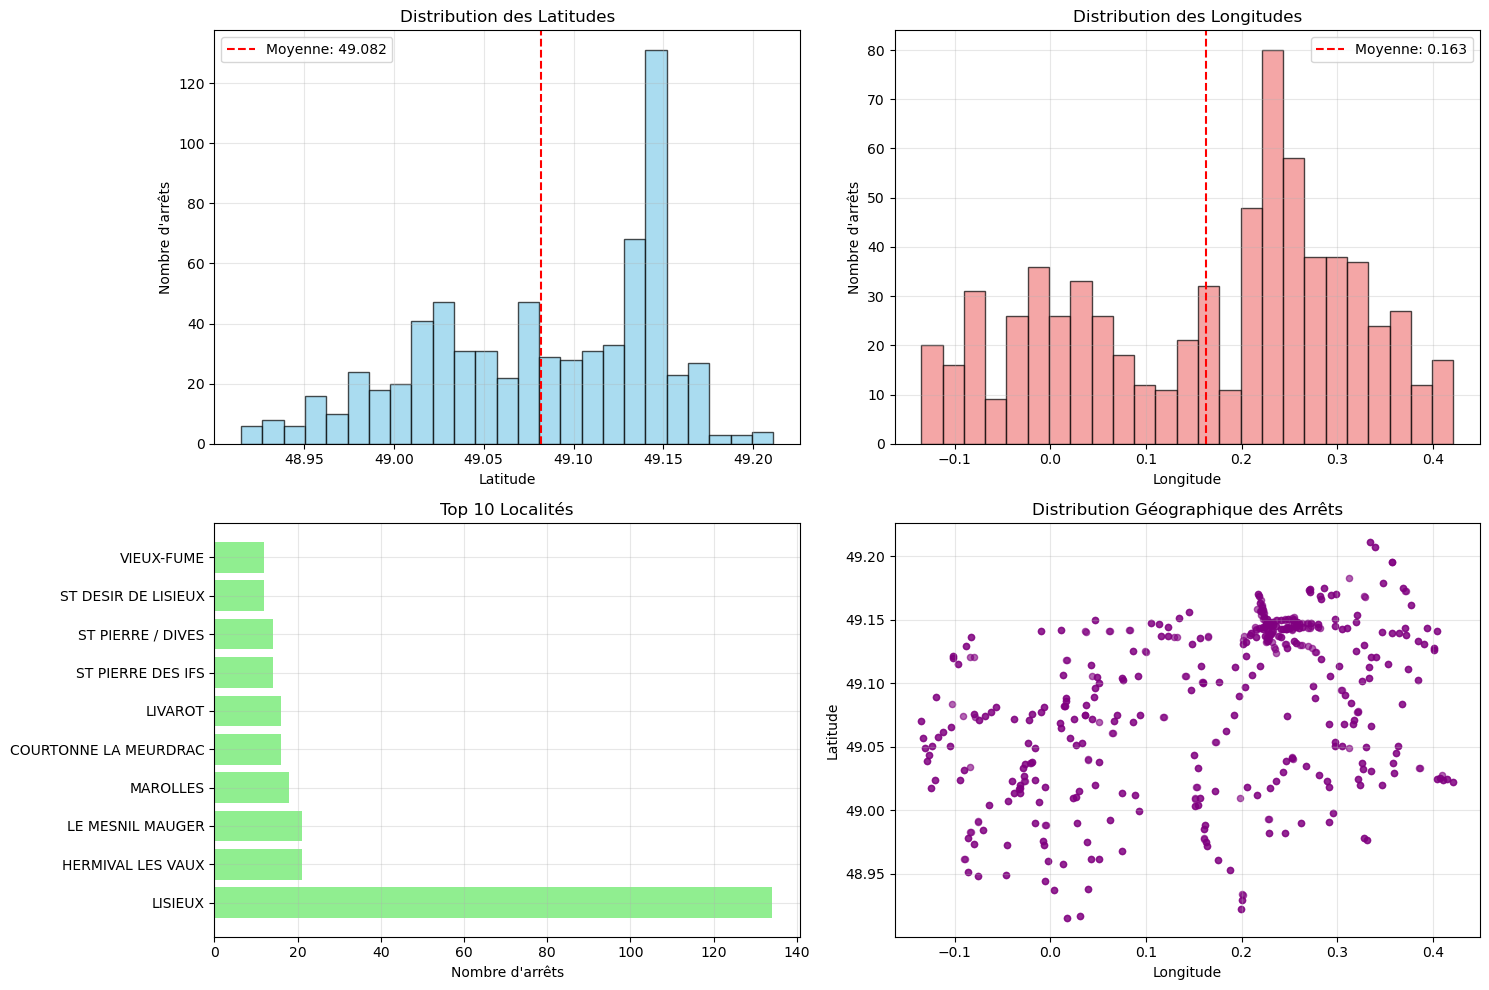

In [92]:
# Cell 12: Visualisations avancées
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("=" * 35)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme latitude
axes[0,0].hist(df_arrets['latitude'], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df_arrets['latitude'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_arrets["latitude"].mean():.3f}')
axes[0,0].set_xlabel('Latitude')
axes[0,0].set_ylabel('Nombre d\'arrêts')
axes[0,0].set_title('Distribution des Latitudes')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Histogramme longitude
axes[0,1].hist(df_arrets['longitude'], bins=25, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0,1].axvline(df_arrets['longitude'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_arrets["longitude"].mean():.3f}')
axes[0,1].set_xlabel('Longitude')
axes[0,1].set_ylabel('Nombre d\'arrêts')
axes[0,1].set_title('Distribution des Longitudes')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Top localités
top_10_loc = df_arrets['localite'].value_counts().head(10)
axes[1,0].barh(range(len(top_10_loc)), top_10_loc.values, color='lightgreen')
axes[1,0].set_yticks(range(len(top_10_loc)))
axes[1,0].set_yticklabels(top_10_loc.index)
axes[1,0].set_xlabel('Nombre d\'arrêts')
axes[1,0].set_title('Top 10 Localités')
axes[1,0].grid(alpha=0.3)

# Scatter plot géographique
axes[1,1].scatter(df_arrets['longitude'], df_arrets['latitude'], alpha=0.6, s=20, color='purple')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
axes[1,1].set_title('Distribution Géographique des Arrêts')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Conclusion et Perspectives

In [93]:
# Cell 13: Synthèse finale
print("📊 SYNTHÈSE FINALE DU PROJET")
print("=" * 35)

print("✅ ACQUIS DE L'ANALYSE :")
print(f"   • {len(df_arrets):,} arrêts analysés avec succès")
print(f"   • {df_arrets['localite'].nunique()} localités couvertes")
print(f"   • Données géographiques complètes et cohérentes")
print(f"   • Cartographie interactive fonctionnelle")

print("\n🎯 PERSPECTIVES :")
print("   • Analyse de densité par carroyage")
print("   • Croisement avec données démographiques INSEE")
print("   • Optimisation des circuits existants")
print("   • Détection des zones sous-desservies")

print(f"\n📍 CARACTÉRISTIQUES DU RÉSEAU :")
print(f"   • Centre : {center_lat:.4f}°N, {center_lon:.4f}°E")
print(f"   • Étendue : {etendue_lat:.3f}° × {etendue_lon:.3f}°")
print(f"   • Localité principale : {top_localites.index[0]} ({top_localites.iloc[0]} arrêts)")

print(f"\n🚀 PROJET PRÊT POUR LE DÉPÔT GITHUB !")

📊 SYNTHÈSE FINALE DU PROJET
✅ ACQUIS DE L'ANALYSE :
   • 707 arrêts analysés avec succès
   • 116 localités couvertes
   • Données géographiques complètes et cohérentes
   • Cartographie interactive fonctionnelle

🎯 PERSPECTIVES :
   • Analyse de densité par carroyage
   • Croisement avec données démographiques INSEE
   • Optimisation des circuits existants
   • Détection des zones sous-desservies

📍 CARACTÉRISTIQUES DU RÉSEAU :
   • Centre : 49.0819°N, 0.1629°E
   • Étendue : 0.296° × 0.557°
   • Localité principale : LISIEUX (134 arrêts)

🚀 PROJET PRÊT POUR LE DÉPÔT GITHUB !
